In [1]:
import torch
import torchvision.datasets as dests
import torchvision.transforms as transforms
import torch.nn.init
import matplotlib.pyplot as plt

In [2]:
# Cuda 선언
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 랜덤 시드 고정
torch.manual_seed(777)

# GPU 사용 가능일 경우 랜덤 시드 고정
if device == 'cuda':
    torch.cuda.manual_seed_all(777)
    print('cuda')

cuda


In [3]:
# 학습 파라미터 설정
learning_rate = 0.001
training_epochs = 50
batch_size = 100

In [4]:
# 데이터셋 정의 (Data Augmentation 추가)
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

cifar_train = dests.CIFAR10(root ='/Users/mbnv6/Project/dataset/CIFAR10_data',
                            train = True,
                            transform= transform_train,
                            download = False)
cifar_test = dests.CIFAR10(root = '/Users/mbnv6/Project/dataset/CIFAR10_data',
                           train = False,
                           transform= transform_test,
                           download = False)

In [5]:
data_loader = torch.utils.data.DataLoader(dataset = cifar_train,
                                          batch_size = batch_size,
                                          shuffle = True,
                                          drop_last = True)

In [6]:
# 데이터셋 크기 확인
print(f'학습 데이터 개수: {len(cifar_train)}')
print(f'테스트 데이터 개수: {len(cifar_test)}')
print(f'이미지 형태: {cifar_train[0][0].shape}')
print(f'배치 개수: {len(data_loader)}')

학습 데이터 개수: 50000
테스트 데이터 개수: 10000
이미지 형태: torch.Size([3, 32, 32])
배치 개수: 500


In [7]:
class CNN(torch.nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.keep_prob = 0.7 # 드롭아웃 확률 (과적합 방지 강화)
        # input image 형태는 (32, 32 , 3 ) # 높이 폭 채널
        # Conv2d 로 출력채널 32개, stride = 1, padding = 1으로 convolution 후의 크기를 보정해줌
        # ReLU = Activation Function
        # MaxPool2d = Kernel size 2x2, stride 2로 down sampling ->> 출력 형태는 (16,16,32)
        self.layer1 = torch.nn.Sequential(
            torch.nn.Conv2d(3, 32, kernel_size= 3, stride= 1, padding = 1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size = 2, stride = 2)
        ) 
        # input 형태는 (16, 16, 32) 
        # Conv2d로 출력채널 64개
        # MaxPool2d 로 down sampling ->> 출력은 8,8,64
        self.layer2 = torch.nn.Sequential(
            torch.nn.Conv2d(32, 64, kernel_size= 3, stride= 1, padding = 1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size = 2, stride =2)
        )
        # input는 8,8,64
        # Conv2d로 출력채널 128개
        # Maxpool2d로 down sampling ->> 출력은 4,4,128
        self.layer3 = torch.nn.Sequential(
            torch.nn.Conv2d(64, 128, kernel_size= 3, stride= 1, padding = 1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size= 2, stride= 2)
        )
        # Fully Connected Layer 1
        # input node = 4x4x128 = 2048, 출력노드는 625 
        # Drop out으로 과적합 방지, p = 0.5
        self.fc1 = torch.nn.Linear(4 * 4 * 128, 625, bias = True)
        torch.nn.init.xavier_uniform_(self.fc1.weight)
        self.layer4 = torch.nn.Sequential(
            self.fc1,
            torch.nn.ReLU(),
            torch.nn.Dropout(p= 1- self.keep_prob)
        )

        # 최종 FC layer
        # input node = 625, 출력 10
        self.fc2 = torch.nn.Linear(625, 10, bias= True)
        torch.nn.init.xavier_uniform_(self.fc2.weight)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        # fc layer 전에 Tensor 펼치기
        out = out.view(out.size(0),-1)
        out = self.layer4(out)
        out = self.fc2(out)
        return out

In [8]:
# 모델 정의
model = CNN().to(device)

In [9]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr= learning_rate, weight_decay=1e-4)  # Weight Decay 추가

In [10]:
total_batch = len(data_loader)
print('총 배치의 수 : {}'.format(total_batch))

총 배치의 수 : 500


In [11]:
# 학습 loss 기록용 리스트
train_losses = []

for epoch in range(training_epochs):
    avg_cost = 0

    for X, Y in data_loader: # 미니 배치 단위로 꺼내온다. X는 미니 배치, Y는 레이블.
        
        X = X.to(device)
        Y = Y.to(device)

        optimizer.zero_grad()
        hypothesis = model(X)
        cost = criterion(hypothesis, Y)
        cost.backward()
        optimizer.step()

        avg_cost += cost / total_batch

    # loss 기록
    train_losses.append(avg_cost.item())
    print('[Epoch: {:>4}] cost = {:>.9}'.format(epoch + 1, avg_cost))

[Epoch:    1] cost = 1.60278678
[Epoch:    2] cost = 1.26296818
[Epoch:    3] cost = 1.12230945
[Epoch:    4] cost = 1.03463948
[Epoch:    5] cost = 0.974384844
[Epoch:    6] cost = 0.921741307
[Epoch:    7] cost = 0.893223405
[Epoch:    8] cost = 0.854525566
[Epoch:    9] cost = 0.829084158
[Epoch:   10] cost = 0.806132674
[Epoch:   11] cost = 0.787402987
[Epoch:   12] cost = 0.769352794
[Epoch:   13] cost = 0.753977418
[Epoch:   14] cost = 0.74522537
[Epoch:   15] cost = 0.725629807
[Epoch:   16] cost = 0.718491256
[Epoch:   17] cost = 0.706828296
[Epoch:   18] cost = 0.693887532
[Epoch:   19] cost = 0.691490889
[Epoch:   20] cost = 0.684736907
[Epoch:   21] cost = 0.66266042
[Epoch:   22] cost = 0.666757822
[Epoch:   23] cost = 0.658745944
[Epoch:   24] cost = 0.650740266
[Epoch:   25] cost = 0.642674029
[Epoch:   26] cost = 0.64119184
[Epoch:   27] cost = 0.633669078
[Epoch:   28] cost = 0.631774604
[Epoch:   29] cost = 0.621440768
[Epoch:   30] cost = 0.617218018
[Epoch:   31] cos

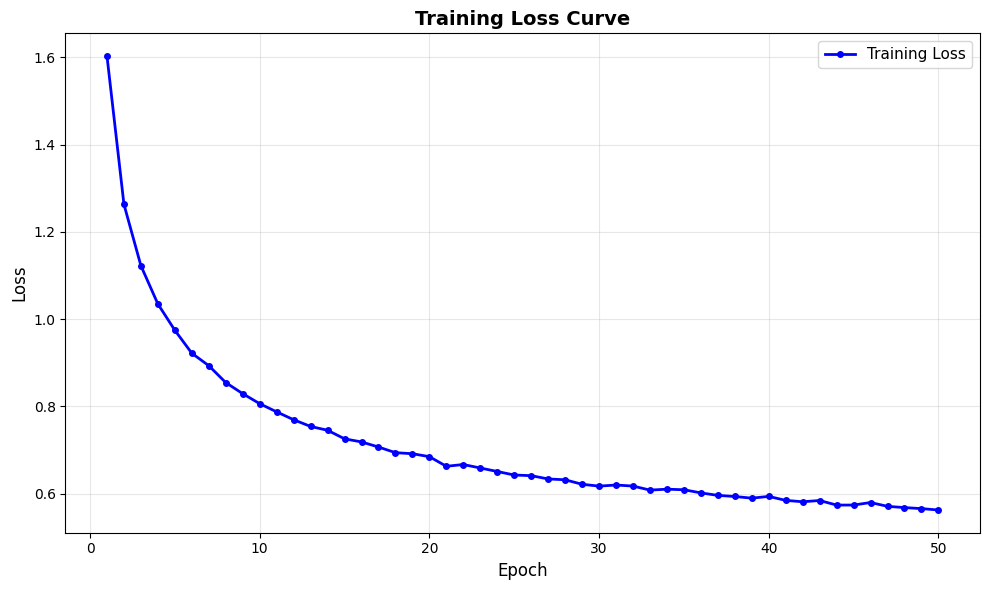


초기 Loss: 1.6028
최종 Loss: 0.5625
Loss 감소량: 1.0403


In [12]:
# 학습 곡선 시각화
plt.figure(figsize=(10, 6))
plt.plot(range(1, training_epochs + 1), train_losses, 'b-', label='Training Loss', linewidth=2, marker='o', markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss Curve', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n초기 Loss: {train_losses[0]:.4f}')
print(f'최종 Loss: {train_losses[-1]:.4f}')
print(f'Loss 감소량: {train_losses[0] - train_losses[-1]:.4f}')

In [13]:
# 테스트 (전처리 일관 + 평가 모드)
from torch.utils.data import DataLoader

# 테스트 데이터 로더: transform_test 적용된 cifar_test 사용
test_loader = DataLoader(cifar_test, batch_size=256, shuffle=False)

model.eval()
correct = 0
total = 0
with torch.no_grad():
    for X, Y in test_loader:
        X, Y = X.to(device), Y.to(device)
        logits = model(X)
        preds = logits.argmax(1)
        correct += (preds == Y).sum().item()
        total += Y.size(0)

accuracy = 100.0 * correct / total
print(f'Accuracy : {accuracy:.2f}%')

# 평가 후 학습 모드로 복귀
model.train()

Accuracy : 82.62%


CNN(
  (layer1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2048, out_features=625, bias=True)
  (layer4): Sequential(
    (0): Linear(in_features=2048, out_features=625, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.30000000000000004, inplace=False)
  )
  (fc2): Linear(in_features=625, out_features=10, bias=True)
)

In [ ]:
# 정확도 향상 방법
# 1. Epochs 증가
# 2. Batch size 늘리기
# 3. Data normalization